In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

In [2]:
pd.set_option('display.max_columns', None)
DATA_DIR = r"C:\glassIDS\data\raw\MachineLearningCVE"

In [3]:
monday_path = os.path.join(DATA_DIR, "Monday-WorkingHours.pcap_ISCX.csv")
df_mon = pd.read_csv(monday_path)

print(df_mon.shape)
print(df_mon.columns.tolist())
df_mon.head()

(529918, 79)
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count'

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,3000000.0,5.000000e+05,4.0,0.0,4,4,4,4.0,0.0,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4000000.0,6.666667e+05,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
df_mon.columns = df_mon.columns.str.strip()
print(df_mon['Label'].value_counts())  # should be all BENIGN

Label
BENIGN    529918
Name: count, dtype: int64


In [5]:
all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print(f"Found {len(all_files)} files")
for f in all_files:
    print(os.path.basename(f))

df_list = []
for f in all_files:
    temp = pd.read_csv(f)
    temp.columns = temp.columns.str.strip()  # fix whitespace on every file
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True) #joined vertically
print(df.shape)
del df_list  # free memory

Found 8 files
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv
(2830743, 79)


In [6]:
print(df.dtypes.value_counts())
print()
print(df['Label'].value_counts())
print()
print(df['Label'].value_counts(normalize=True) * 100)  # % share — the imbalance, in numbers

int64      54
float64    24
str         1
Name: count, dtype: int64

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Label
BENIGN                        80.300366
DoS Hulk                       8.162981
PortScan                       5.614427
DDoS                           4.522735
DoS GoldenEye                  0.363615
FTP-Patator                    0.280421
SSH-Patator                    0.208320
DoS slowloris                  0.204752
Do

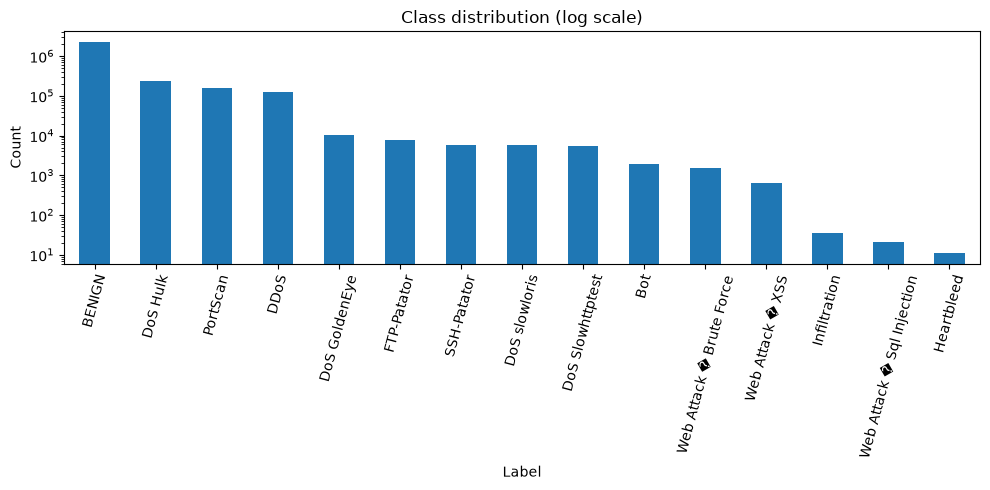

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

df['Label'].value_counts().plot(kind='bar', ax=ax)

ax.set_yscale('log')  # log scale — otherwise the attack bars are invisible next to BENIGN
ax.set_title('Class distribution (log scale)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

inf_counts = np.isinf(df[numeric_cols]).sum()
print("Columns with infinite values:")
print(inf_counts[inf_counts > 0])

nan_counts = df[numeric_cols].isna().sum()
print("\nColumns with NaN values:")
print(nan_counts[nan_counts > 0])

Columns with infinite values:
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64

Columns with NaN values:
Flow Bytes/s    1358
dtype: int64


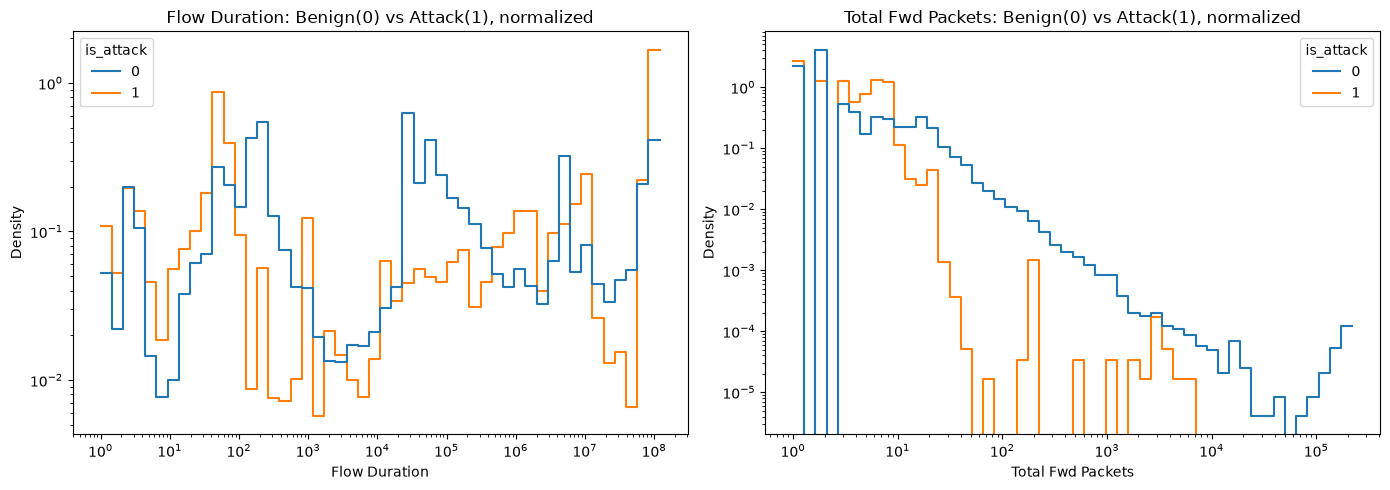

In [12]:
df['is_attack'] = (df['Label'] != 'BENIGN').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flow Duration — clip extreme outliers for a readable plot
sns.histplot(data=df, x='Flow Duration', hue='is_attack', bins=50,
             log_scale=True, stat='density', common_norm=False,
             element='step', fill=False, linewidth=1.5, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration: Benign(0) vs Attack(1), normalized')

# Total Fwd Packets
sns.histplot(data=df, x='Total Fwd Packets', hue='is_attack', bins=50,
             log_scale=True, stat='density', common_norm=False,
             element='step', fill=False, linewidth=1.5, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Total Fwd Packets: Benign(0) vs Attack(1), normalized')

plt.tight_layout()
plt.show()

In [12]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Recheck
nan_counts_after = df[numeric_cols].isna().sum()
print(nan_counts_after[nan_counts_after > 0])
print(f"\nTotal rows with any NaN: {df.isna().any(axis=1).sum()} out of {len(df)}")

Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64

Total rows with any NaN: 2867 out of 2830743


In [13]:
rows_before = len(df)
df.dropna(inplace=True)
rows_after = len(df)
print(f"Dropped {rows_before - rows_after} rows ({(rows_before - rows_after)/rows_before*100:.3f}%)")

Dropped 2867 rows (0.101%)


In [14]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes} ({dupes/len(df)*100:.3f}%)")

df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Duplicate rows: 307078 (10.859%)
Shape after dropping duplicates: (2520798, 80)


In [18]:
# CIC-IDS2017 is known to have inconsistent label spellings across files
# (e.g. 'Web Attack – Brute Force' with different dash characters, casing variants)
print(sorted(df['Label'].unique()))

['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [20]:
df['Label'] = df['Label'].str.strip()

df['Label'] = df['Label'].str.replace(
    r'Web Attack.+Brute Force', 'Web Attack - Brute Force', regex=True
)
df['Label'] = df['Label'].str.replace(
    r'Web Attack.+XSS', 'Web Attack - XSS', regex=True
)
df['Label'] = df['Label'].str.replace(
    r'Web Attack.+Sql Injection', 'Web Attack - Sql Injection', regex=True
)

print(sorted(df['Label'].unique()))

['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Label
BENIGN                        83.110864
DoS Hulk                       6.856797
DDoS                           5.078313
PortScan                       3.597829
DoS GoldenEye                  0.408045
FTP-Patator                    0.235283
DoS slowloris                  0.213623
DoS Slowhttptest               0.207395
SSH-Patator                    0.127698
Bot                            

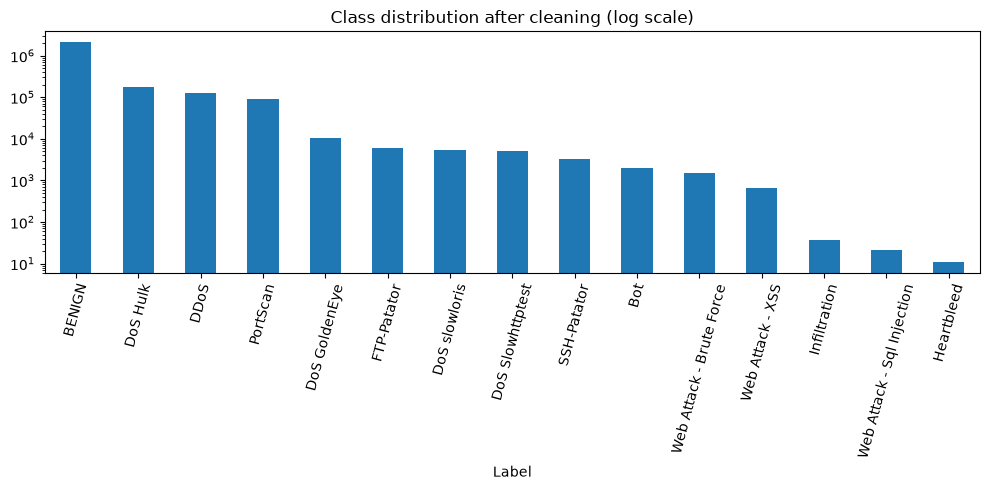

In [21]:
print(df['Label'].value_counts())
print()
print(df['Label'].value_counts(normalize=True) * 100)

plt.figure(figsize=(10, 5))
df['Label'].value_counts().plot(kind='bar')
plt.yscale('log')
plt.title('Class distribution after cleaning (log scale)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [23]:
OUTPUT_DIR = r"C:\glassIDS\data\processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)
df.to_csv(os.path.join(OUTPUT_DIR, "cicids2017_cleaned.csv"), index=False)
print("Saved.")

Saved.
